### Импорт библиотек и загрузка изображения

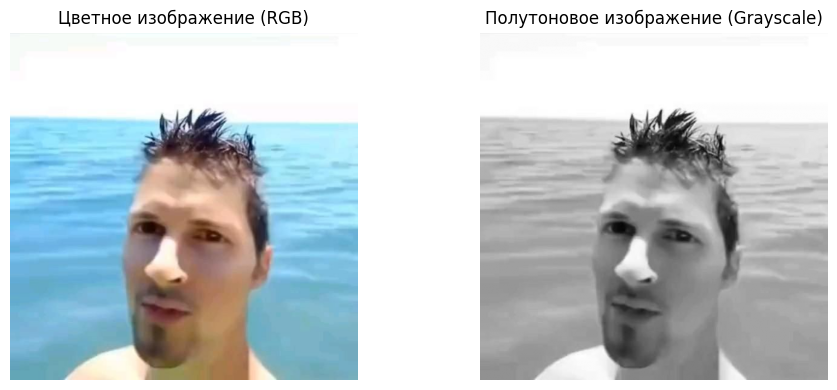

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread('image.jpg')
img_gray = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Цветное изображение (RGB)')
axes[0].axis('off')

axes[1].imshow(img_gray, cmap='gray')
axes[1].set_title('Полутоновое изображение (Grayscale)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Задание 1.  Построить гистограмму изображения и определить минимум, максимум и медиану яркости.

Минимальная яркость: 6
Максимальная яркость: 255
Медиана яркости: 179.0


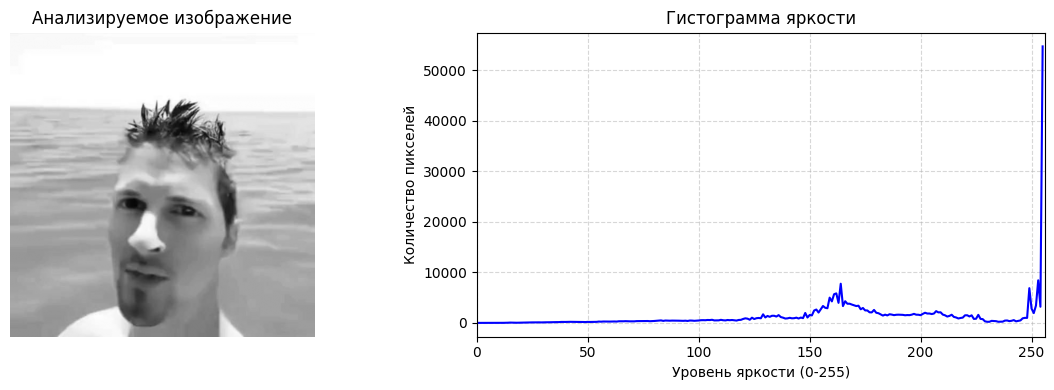

In [2]:
min_val = np.min(img_gray)
max_val = np.max(img_gray)
median_val = np.median(img_gray)

print(f'Минимальная яркость: {min_val}')
print(f'Максимальная яркость: {max_val}')
print(f'Медиана яркости: {median_val}')

hist = cv2.calcHist([img_gray], [0], None, [256], [0, 256])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title('Анализируемое изображение')
axes[0].axis('off')

axes[1].plot(hist, color='blue', linewidth=1.5)
axes[1].set_title('Гистограмма яркости')
axes[1].set_xlabel('Уровень яркости (0-255)')
axes[1].set_ylabel('Количество пикселей')
axes[1].set_xlim([0, 256])
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Задание 2. Построить профили изображения после применения фильтра «Собель» по X и Y.

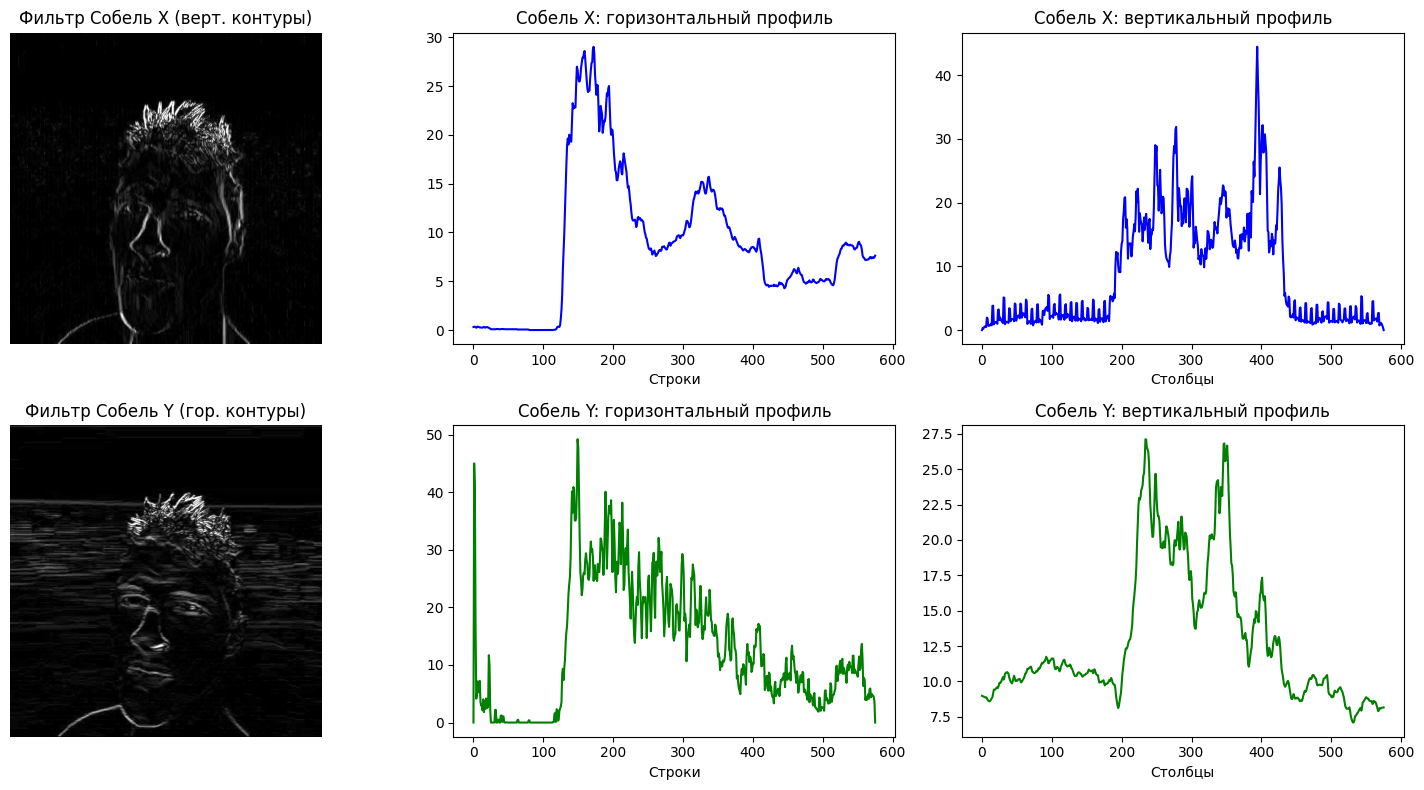

In [3]:
sobel_x = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)

sobel_x = cv2.convertScaleAbs(sobel_x)
sobel_y = cv2.convertScaleAbs(sobel_y)

prof_hx = np.mean(sobel_x, axis=1)
prof_vx = np.mean(sobel_x, axis=0)

prof_hy = np.mean(sobel_y, axis=1)
prof_vy = np.mean(sobel_y, axis=0)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Верхний ряд: Собель X (изображение и 2 профиля)
axes[0, 0].imshow(sobel_x, cmap='gray')
axes[0, 0].set_title('Фильтр Собель X (верт. контуры)')
axes[0, 0].axis('off')

axes[0, 1].plot(prof_hx, color='blue')
axes[0, 1].set_title('Собель X: горизонтальный профиль')
axes[0, 1].set_xlabel('Строки')

axes[0, 2].plot(prof_vx, color='blue')
axes[0, 2].set_title('Собель X: вертикальный профиль')
axes[0, 2].set_xlabel('Столбцы')

# Нижний ряд: Собель Y (изображение и 2 профиля)
axes[1, 0].imshow(sobel_y, cmap='gray')
axes[1, 0].set_title('Фильтр Собель Y (гор. контуры)')
axes[1, 0].axis('off')

axes[1, 1].plot(prof_hy, color='green')
axes[1, 1].set_title('Собель Y: горизонтальный профиль')
axes[1, 1].set_xlabel('Строки')

axes[1, 2].plot(prof_vy, color='green')
axes[1, 2].set_title('Собель Y: вертикальный профиль')
axes[1, 2].set_xlabel('Столбцы')

plt.tight_layout()
plt.show()

### Задание 3. Построить горизонтальную и вертикальную проекции цветного изображения (суммируя по каналам).

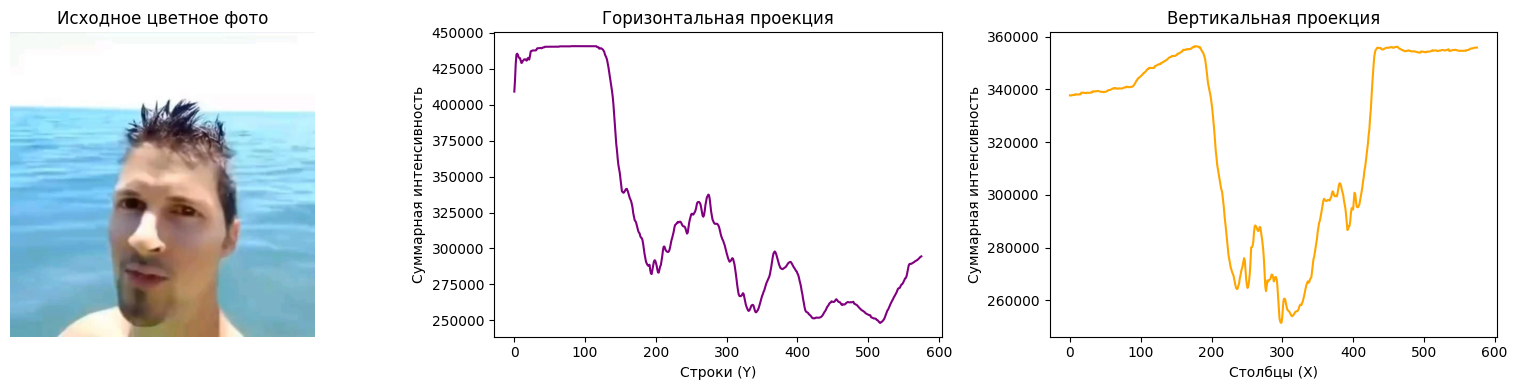

In [4]:
img_sum_channels = np.sum(img, axis=2)

proj_h_color = np.sum(img_sum_channels, axis=1)
proj_v_color = np.sum(img_sum_channels, axis=0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Фото кадра
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Исходное цветное фото')
axes[0].axis('off')

# Горизонтальная проекция
axes[1].plot(proj_h_color, color='purple')
axes[1].set_title('Горизонтальная проекция')
axes[1].set_xlabel('Строки (Y)')
axes[1].set_ylabel('Суммарная интенсивность')

# Вертикальная проекция
axes[2].plot(proj_v_color, color='orange')
axes[2].set_title('Вертикальная проекция')
axes[2].set_xlabel('Столбцы (X)')
axes[2].set_ylabel('Суммарная интенсивность')

plt.tight_layout()
plt.show()

### Задание 4. Найти строки с пикселями выше порога в горизонтальной проекции бинарного изображения.

Порог для горизонтальной проекции: 129248.7
Количество строк выше порога: 279
Первые 10 найденных строк: [0 1 2 3 4 5 6 7 8 9]


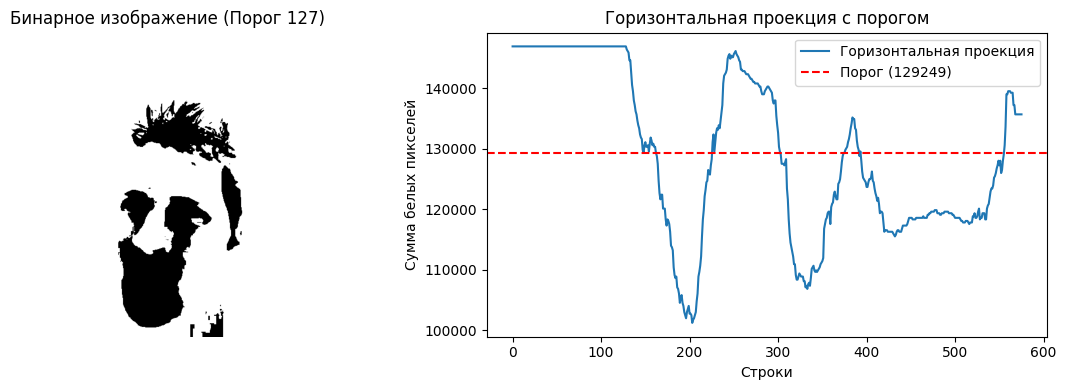

In [5]:
_, img_bin = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)

proj_bin_h = np.sum(img_bin, axis=1)

threshold_row = np.mean(proj_bin_h)

rows_above_thresh = np.where(proj_bin_h > threshold_row)[0]

print(f'Порог для горизонтальной проекции: {threshold_row:.1f}')
print(f'Количество строк выше порога: {len(rows_above_thresh)}')
print('Первые 10 найденных строк:', rows_above_thresh[:10])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Бинарная фотография
axes[0].imshow(img_bin, cmap='gray')
axes[0].set_title('Бинарное изображение (Порог 127)')
axes[0].axis('off')

# График горизонтальной проекции с линией порога
axes[1].plot(proj_bin_h, label='Горизонтальная проекция')
axes[1].axhline(
    y=threshold_row,
    color='r',
    linestyle='--',
    label=f'Порог ({threshold_row:.0f})',
)
axes[1].set_title('Горизонтальная проекция с порогом')
axes[1].set_xlabel('Строки')
axes[1].set_ylabel('Сумма белых пикселей')
axes[1].legend()

plt.tight_layout()
plt.show()

### Задание 5. Найти столбцы с пикселями выше порога в вертикальной проекции бинарного изображения.

Порог для вертикальной проекции: 129248.7
Количество столбцов выше порога: 359
Первые 10 найденных столбцов: [0 1 2 3 4 5 6 7 8 9]


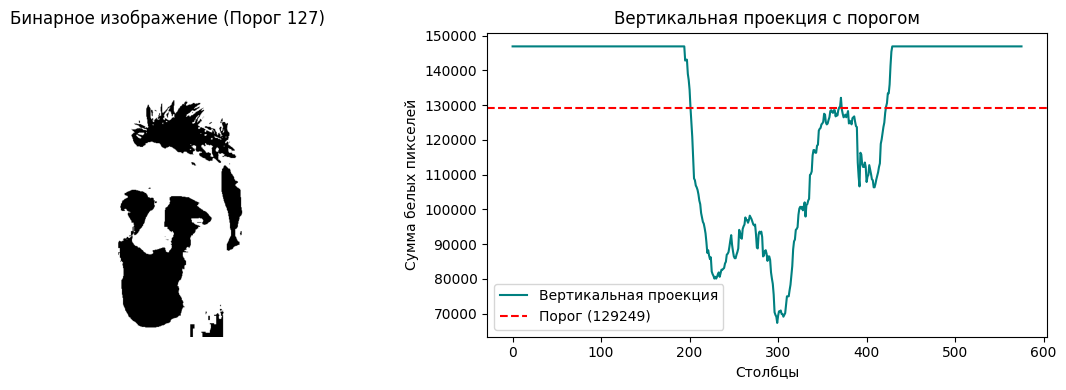

In [6]:
proj_bin_v = np.sum(img_bin, axis=0)

threshold_col = np.mean(proj_bin_v)

cols_above_thresh = np.where(proj_bin_v > threshold_col)[0]

print(f'Порог для вертикальной проекции: {threshold_col:.1f}')
print(f'Количество столбцов выше порога: {len(cols_above_thresh)}')
print('Первые 10 найденных столбцов:', cols_above_thresh[:10])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Бинарная фотография
axes[0].imshow(img_bin, cmap='gray')
axes[0].set_title('Бинарное изображение (Порог 127)')
axes[0].axis('off')

# График вертикальной проекции с линией порога
axes[1].plot(proj_bin_v, color='teal', label='Вертикальная проекция')
axes[1].axhline(
    y=threshold_col,
    color='r',
    linestyle='--',
    label=f'Порог ({threshold_col:.0f})',
)
axes[1].set_title('Вертикальная проекция с порогом')
axes[1].set_xlabel('Столбцы')
axes[1].set_ylabel('Сумма белых пикселей')
axes[1].legend()

plt.tight_layout()
plt.show()